# 🧠 Introduction
Designing an AI that never loses in a game might sound like magic—but in many classic games, it’s simply a matter of strategy and computation. In this notebook, we’ll explore one such strategy: the **Minimax algorithm**, a recursive decision-making process commonly used in two-player games. Without diving too deep just yet, you can think of Minimax as a way for the AI to simulate every possible move—both its own and its opponent’s—and then choose the path that leads to the best possible outcome. It’s a form of perfect play.

To demonstrate the power of Minimax, we’ll use a simple yet intellectually rich playground: **Tic-Tac-Toe.**

# ⭕️ ❌ Tic-Tac-Toe: A Gentle Primer
Tic-Tac-Toe, also known as Noughts and Crosses, is a two-player game played on a **3x3 grid**. Players take turns marking a square—one with an X, the other with an O. The goal is to place three of your own symbols in a row: horizontally, vertically, or diagonally.

Despite its simplicity, Tic-Tac-Toe has some fascinating properties:
- There are only **9 possible moves** to start, but many sequences to explore.
- If both players play perfectly, the game always ends in a **draw**.
- It's often the first game used to teach algorithms like **Minimax**, because of its limited but rich decision space.

For those unfamiliar, here’s what a game might look like halfway through:

```
 O | X | O
---+---+---
 X |   | X
---+---+---
   | O | 

```

In this notebook, we’ll walk through how to make an AI that plays Tic-Tac-Toe perfectly—meaning it will **never lose**, no matter how good or bad its opponent is.

# Minimax Algorithm (Short Story)
The minimax algorithm is a fundamental procedure for decision-making in two-player, zero-sum games: it systematically explores the entire game tree by alternating between “maximizing” layers (where the current player seeks to maximize their score) and “minimizing” layers (where the opponent seeks to minimize that same score), ultimately computing the optimal value of each possible move under perfect play. 

Starting from the root node (the current game state), minimax recursively generates all legal moves for the active player, simulates each move to produce child states, and then switches perspective: if it was the maximizing player’s turn, the recursion next treats the opponent as minimizing, and vice versa. When a terminal state—a win, loss, or draw—is reached, a utility function assigns it a numerical score (e.g., +1 for a win, –1 for a loss, 0 for a draw). As the recursion unwinds, minimizing nodes propagate upward the minimum of their children’s scores (i.e., the opponent will choose the move least favorable to the maximizer), while maximizing nodes propagate the maximum (i.e., the player selects the move most favorable to themselves). 

By exhaustively evaluating the entire tree, minimax guarantees that the chosen action at the root maximizes the player’s guaranteed outcome assuming the opponent also plays optimally; its worst-case time complexity is exponential in the depth of the tree (O(b^d) for branching factor b and depth d), though practical implementations frequently incorporate alpha-beta pruning to eliminate large swaths of branches that cannot affect the final decision, reducing the effective search space without changing the result.

Okay, that was a pretty compact explanation of the algorithm. Let's break it down step by step so that we understand the concept better.

# Minimax Algorithm (Long Story)
Let´s start with the initial state of the tic-tac-toe board which looks like that:

```
 O | X | O
---+---+---
 X |   | X
---+---+---
   | O | 

```

*Yes, I know, the board is already well filled, but I think the concept of the algorithm is also very clear here. Perhaps even better than if we were to start from scratch.* 

First, we note that `X` hast three marks and `O` has three marks, so it´s `O´s` turn to play. At this point, there are three empty squares - let´s call them `A` at `(1,1)`, `B` at `(2,0)` and `C` at `(2,2)` - and each repreents a distict branch in the game tree. 

To apply Minimax, we start at the root (the current board) and recursively simulate each of `O´s` possible moves. For each move (say O -> A), we create a child node by playing `O` in `A` and the switch to `X´s` turn. We continue expanding children (`X´s` replies, then `O´s` replies, and so on) unitl we fill the board or somebody wins. 

Let´s have a closer look at the next stages. So I am `O` and obviously, my goal is to maximize my end game score. 

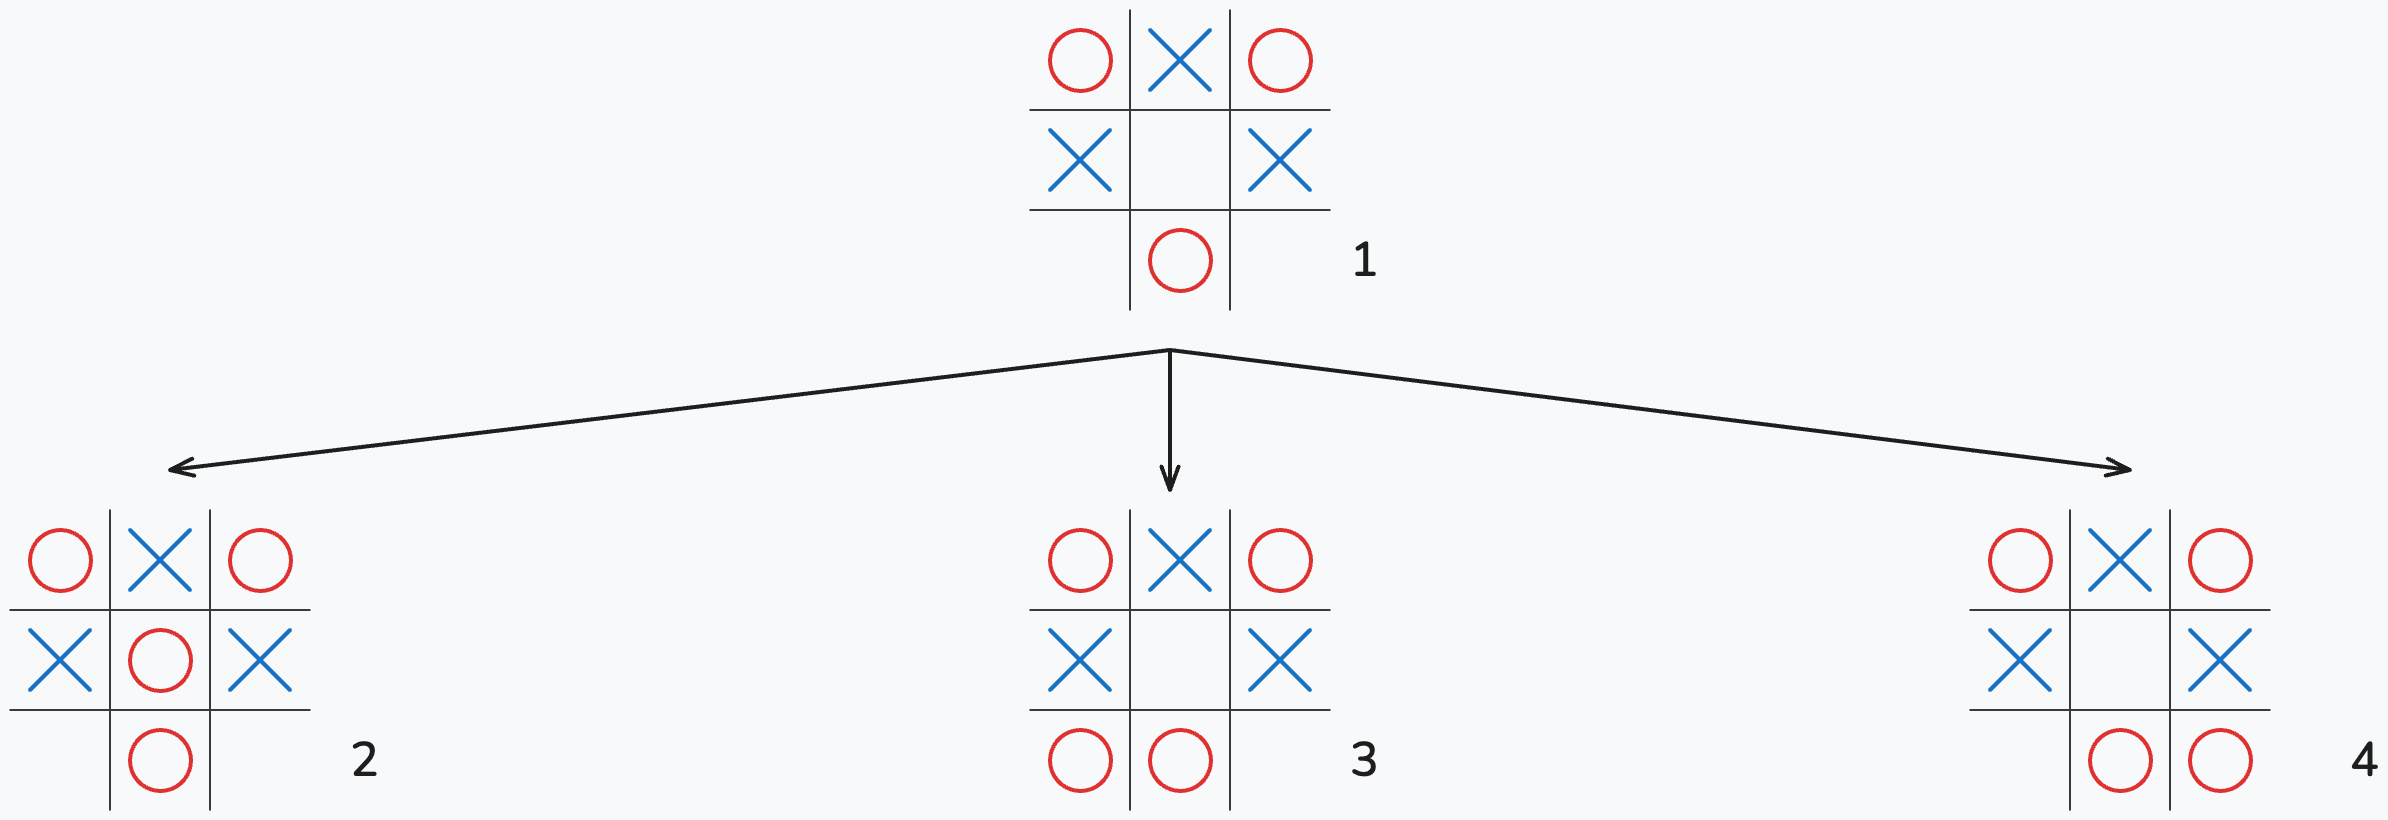

In [1]:
from IPython.display import Image
Image("/kaggle/input/minimax-tmp-helper/stage1.png")

So again, if the top of this image represents the state of the game and it´s my turn (`O`s), there are three places I can play, none of which clearly results in me winning and earning one point. 
The next move will be done from `X`. What do we know about `X`? Well we should assume that `X` has also the plan to win this game. Compared to us `X` mission is to choose the worst score for us, so it wants to pick a move that minimizes our score. Let´s print all possible states of this round and have a closer look on it. So will will understand the concept of this algorithm the best. 

At the bottom of the three are the terminal states: if `O` wins, the score is **+1**, and if `X` wins, the score is **-1**. Working upwards, each internal node´s value is determined by whose turn it is: `O` chooses the maximum of its children (trying to maximize the score), while `X` chooses the minimum (trying to minimize my score). On the left side, moving into state 2 ensures that whichever branch `X` chosses (states 5 or 6), I can still forece a win, so its value is **+1**. In the middle branch (state 3), `X` can steer the game into state 7 where `X` wins, so the overall outcome there is **-1**. On the right side (state 4), the same situation happens: `X` can avoid letting me win and force me into a loss, so its value is **-1**. Back at the root (state 1), since its my turn as `O` I compare the outcomd of the three options: **+1** (left) **-1** (middle) and **-1** (right). 
Following minimax, I select the move leading to state 2, because it guarantees me the maximum possible outcome, which is a forced win by me. 

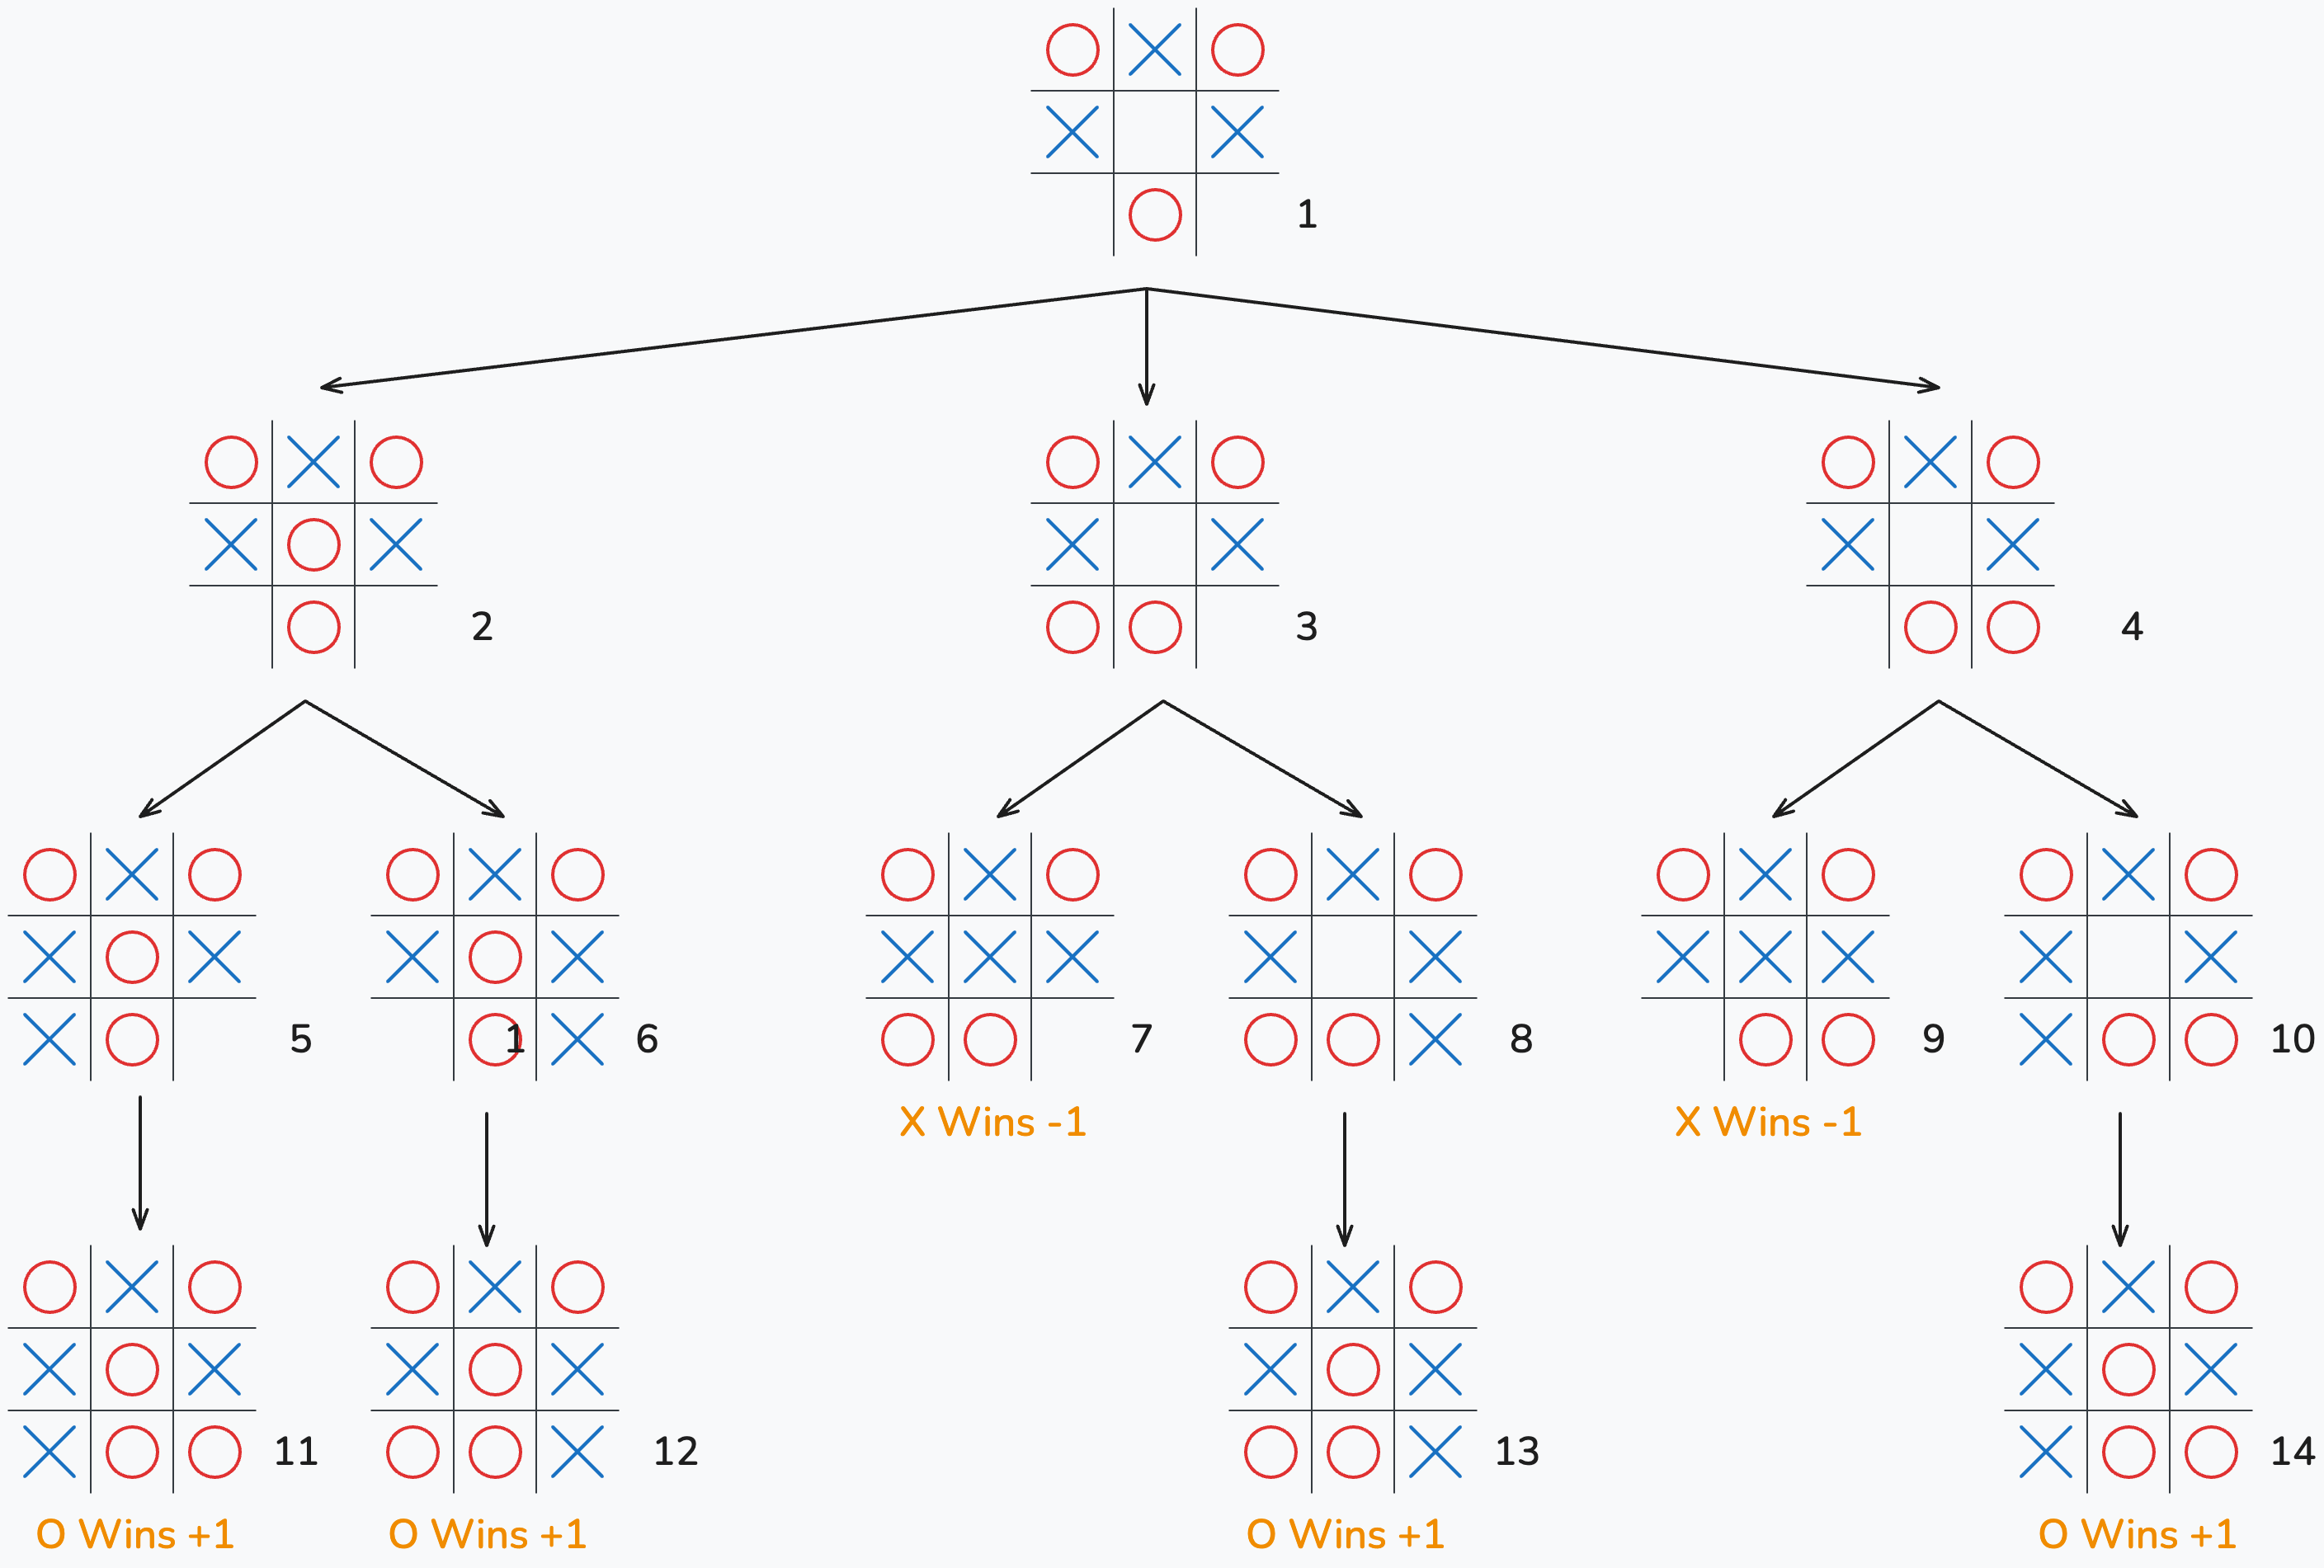

In [2]:
from IPython.display import Image
Image("/kaggle/input/minimax-tmp-helper/stage2.png")

At the bottom of the three are the terminal states: if `O` wins, the score is **+1**, and if `X` wins, the score is **-1**. Working upwards, each internal node´s value is determined by whose turn it is: `O` chooses the maximum of its children (trying to maximize the score), while `X` chooses the minimum (trying to minimize my score). On the left side, moving into state 2 ensures that whichever branch `X` chosses (states 5 or 6), I can still forece a win, so its value is **+1**. In the middle branch (state 3), `X` can steer the game into state 7 where `X` wins, so the overall outcome there is **-1**. On the right side (state 4), the same situation happens: `X` can avoid letting me win and force me into a loss, so its value is **-1**. Back at the root (state 1), since its my turn as `O` I compare the outcomd of the three options: **+1** (left) **-1** (middle) and **-1** (right). 
Following minimax, I select the move leading to state 2, because it guarantees me the maximum possible outcome, which is a forced win by me. 

# 🐍 The Code
Now that we know how the algorithm works, it's time to develop it in Python.

In [3]:
import copy
from typing import List, Tuple, Optional

The first block defines the TicTacToe class, which is responsible for handling the game state and rules. It initializes the game board as a 3×3 grid and provides methods for listing available moves, making moves by returning a new board state, and checking whether a player has won by evaluating rows, columns, and diagonals. It also includes helper methods to check if the board is full and to determine whether the game has reached a terminal state (a win or a draw). Finally, the print_board method makes it easy to visualize the current board in the console. This block essentially encapsulates all the mechanics needed to play tic-tac-toe.

In [4]:
class TicTacToe:
    def __init__(self, board: List[List[str]] = None):
        self.board = board if board else [['' for _ in range(3)] for _ in range(3)]

    def get_available_moves(self) -> List[Tuple[int, int]]:
        return [(i, j) for i in range(3) for j in range(3) if self.board[i][j] == '']

    def make_move(self, row: int, col: int, player: str) -> 'TicTacToe':
        new_board = copy.deepcopy(self.board)
        new_board[row][col] = player
        return TicTacToe(new_board)

    def check_winner(self) -> Optional[str]:
        lines = (
            self.board +
            [list(col) for col in zip(*self.board)] +
            [[self.board[i][i] for i in range(3)]] +
            [[self.board[i][2 - i] for i in range(3)]]
        )
        for line in lines:
            if line[0] != '' and all(cell == line[0] for cell in line):
                return line[0]
        return None

    def is_full(self) -> bool:
        return all(cell != '' for row in self.board for cell in row)

    def is_terminal(self) -> bool:
        return self.check_winner() is not None or self.is_full()

    def print_board(self):
        print("\nCurrent board:")
        for row in self.board:
            print(['_' if cell == '' else cell for cell in row])
        print()

The second block introduces the `MinimaxAI` class, which contains the logic for the computer player. It sets the AI’s symbol (X or O) and the opponent’s symbol accordingly. The key component is the `minimax` algorithm, a recursive function that evaluates all possible game states. When it is the AI’s turn, the algorithm maximizes the score, while on the human’s turn, it assumes the opponent will minimize the score. The `evaluate` function scores terminal states as +1 for an AI win, –1 for a human win, and 0 for a draw. Finally, the `find_best_move` method tests all available moves, runs minimax on them, and picks the one with the best score, ensuring the AI always plays optimally.

In [5]:
class MinimaxAI:
    def __init__(self, ai_player: str):
        self.ai_player = ai_player
        self.human_player = 'X' if ai_player == 'O' else 'O'

    def evaluate(self, game: TicTacToe) -> int:
        winner = game.check_winner()
        if winner == self.ai_player:
            return 1
        elif winner == self.human_player:
            return -1
        return 0

    def minimax(self, game: TicTacToe, is_maximizing: bool) -> int:
        if game.is_terminal():
            return self.evaluate(game)

        if is_maximizing:
            best_score = float('-inf')
            for row, col in game.get_available_moves():
                new_game = game.make_move(row, col, self.ai_player)
                score = self.minimax(new_game, False)
                best_score = max(best_score, score)
            return best_score
        else:
            best_score = float('inf')
            for row, col in game.get_available_moves():
                new_game = game.make_move(row, col, self.human_player)
                score = self.minimax(new_game, True)
                best_score = min(best_score, score)
            return best_score

    def find_best_move(self, game: TicTacToe) -> Tuple[int, int]:
        best_score = float('-inf')
        best_move = None
        for row, col in game.get_available_moves():
            new_game = game.make_move(row, col, self.ai_player)
            score = self.minimax(new_game, False)
            if score > best_score:
                best_score = score
                best_move = (row, col)
        return best_move

The third block defines the `run_game` function, which creates the interactive gameplay loop. It begins by asking the player whether they want to be X or O, sets up the board and AI accordingly, and starts the game with X always going first. During the game loop, the human is prompted to enter a move, which is validated for correctness, while the AI calculates its best move using minimax. After each move, the board is printed to the console, and the turn alternates. The loop continues until a terminal state is reached, at which point the function checks for a winner and announces the result, or declares a draw if the board is full with no winner. This block ties everything together by managing user interaction, AI decisions, and overall game flow.

In [6]:
def run_game():
    print("🎮 Welcome to Tic-Tac-Toe!")
    while True:
        human = input("Do you want to be X or O? ").strip().upper()
        if human in ['X', 'O']:
            break
        print("Please enter 'X' or 'O'.")

    ai = 'O' if human == 'X' else 'X'
    game = TicTacToe()
    ai_player = MinimaxAI(ai)
    current_player = 'X'  # X always starts

    game.print_board()

    while not game.is_terminal():
        if current_player == human:
            while True:
                try:
                    move = input(f"Your move ({human}) - enter row and column (e.g., 0 2): ")
                    row, col = map(int, move.strip().split())
                    if (row, col) in game.get_available_moves():
                        game = game.make_move(row, col, human)
                        break
                    else:
                        print("❌ Invalid move. Cell is occupied or out of bounds.")
                except Exception:
                    print("⚠️ Invalid input format. Enter two numbers between 0 and 2 separated by space.")
        else:
            print(f"🤖 AI ({ai}) is thinking...")
            row, col = ai_player.find_best_move(game)
            print(f"AI places {ai} at ({row}, {col})")
            game = game.make_move(row, col, ai)

        game.print_board()
        current_player = 'O' if current_player == 'X' else 'X'

    winner = game.check_winner()
    if winner:
        print(f"🏆 Game Over! Winner: {winner}")
    else:
        print("🤝 Game Over! It's a draw.")

In [7]:
# Uncomment this to run the script
#run_game()

This is an example run
```
🎮 Welcome to Tic-Tac-Toe!
Do you want to be X or O?  X

Current board:
['_', '_', '_']
['_', '_', '_']
['_', '_', '_']

Your move (X) - enter row and column (e.g., 0 2):  0 0

Current board:
['X', '_', '_']
['_', '_', '_']
['_', '_', '_']

🤖 AI (O) is thinking...
AI places O at (1, 1)

Current board:
['X', '_', '_']
['_', 'O', '_']
['_', '_', '_']

Your move (X) - enter row and column (e.g., 0 2):  0 1

Current board:
['X', 'X', '_']
['_', 'O', '_']
['_', '_', '_']

🤖 AI (O) is thinking...
AI places O at (0, 2)

Current board:
['X', 'X', 'O']
['_', 'O', '_']
['_', '_', '_']

Your move (X) - enter row and column (e.g., 0 2):  2 0

Current board:
['X', 'X', 'O']
['_', 'O', '_']
['X', '_', '_']

🤖 AI (O) is thinking...
AI places O at (1, 0)

Current board:
['X', 'X', 'O']
['O', 'O', '_']
['X', '_', '_']

Your move (X) - enter row and column (e.g., 0 2):  1 2

Current board:
['X', 'X', 'O']
['O', 'O', 'X']
['X', '_', '_']

🤖 AI (O) is thinking...
AI places O at (2, 1)

Current board:
['X', 'X', 'O']
['O', 'O', 'X']
['X', 'O', '_']

Your move (X) - enter row and column (e.g., 0 2):  2 2

Current board:
['X', 'X', 'O']
['O', 'O', 'X']
['X', 'O', 'X']

🤝 Game Over! It's a draw.
```

# 🔚 Final Words
To conclude, this notebook clearly demonstrates the power of the minimax algorithm in a simple yet complete setting: the game of tic-tac-toe. By systematically exploring all possible future moves and counter-moves, the AI is able to guarantee the best possible outcome regardless of how the human opponent plays. Even in a small game like tic-tac-toe, minimax highlights the core principle of optimal decision-making under adversarial conditions, a concept that extends far beyond board games into fields like operations research, game theory, and artificial intelligence. Through the combination of clean game logic, a recursive search strategy, and an interactive loop, this project showcases not only how minimax ensures perfect play but also how such algorithms can be translated into practical, working code. It serves as a strong foundation for understanding more advanced techniques, such as alpha–beta pruning, and illustrates why minimax remains one of the most fundamental algorithms in AI.

Please give me a ❤️ if you liked this notebook. 